<a href="https://colab.research.google.com/github/matinbyrml/Neural-Networks/blob/main/AMLlab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

data = [[1,2],[3,4]]
x_data = torch.tensor(data)

x_ones = torch.ones_like(x_data)
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float)
print(f"Random Tensor :\n {x_rand} \n")


tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device that i am storing my tensor: {tensor.device}")

if torch.cuda.is_available():
  tensor = tensor.to('cuda')
  print(f"Device that i am storing my tensor: {tensor.device}")



tensor = torch.ones(4,4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:,0]}")
print(f"Last column: {tensor[...,-1]}")
tensor[:,1] = 0
print(tensor)


y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(tensor)

print(y1)
print(y2)


Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor :
 tensor([[0.1281, 0.2154],
        [0.2726, 0.9406]]) 

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device that i am storing my tensor: cpu
Device that i am storing my tensor: cuda:0
First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.1MB/s]


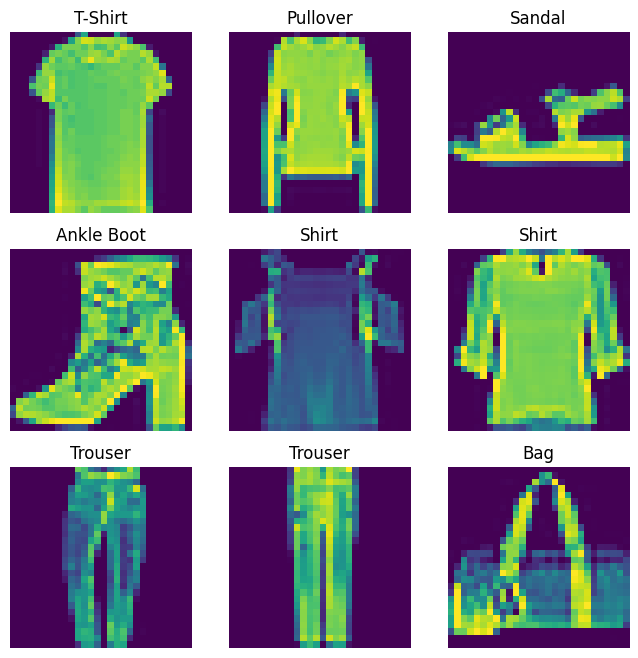

In [ ]:
import torch #import pytorch

from torch.utils.data import Dataset
from torchvision import datasets #import ready to use dataset like FashionMNIST
from torchvision.transforms import ToTensor, Lambda #tool to transfer from image to tensors
import matplotlib.pyplot as plt

# create a dataset for trianing and save it in folder "root"

# it returns (image_tensor, label_integer) for traning_data[i]
# since it probably implements
# def __getitem__(self, index):
#    image = ...  # load image
#    label = ...  # load label
#    if self.transform:
#        image = self.transform(image)
#    return image, label

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True, #download if not already in root folder
    transform=ToTensor() #everytime we ask for an image, get a tensor of it
    )
#same logic applies also here
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
    )
#create a labels map, a python dictionary (key,value)
labels_map = {
0: "T-Shirt",
1: "Trouser",
2: "Pullover",
3: "Dress",
4: "Coat",
5: "Sandal",
6: "Shirt",
7: "Sneaker",
8: "Bag",
9: "Ankle Boot",}
#for example labels_map[8] = "Bag"

#set up the grid
figure = plt.figure(figsize=(8,8))#blank window to draw on, 8x8 inches size
cols, rows = 3, 3 #shape of our grid, 3 rows and 3 cols
#create a loop for 9 random images and plot them
for i in range(1, cols * rows + 1):
  #get a random sample index for a single number between 0 and total number of samples
  sample_idx = torch.randint(len(training_data), size=(1,)).item()
  #get the image and its label with that index
  img, label = training_data[sample_idx] #get the image and its label
  figure.add_subplot(rows, cols, i) #add it to the plot
  plt.title(labels_map[label]) #add label as a title
  plt.axis("off") #turn off y and x axis
  plt.imshow(img.squeeze())

plt.show()

In [ ]:
## How to create a custom custom DataSet class?
# so we can load any folder of images.
# as long as we have annotations_file which lists which image
# corresponds to which label

import os # to work with os, like finding files and paths
import torch
import pandas as pd # useful to read csv files
from torch.utils.data import Dataset
from torchvision.io import read_image  # useful especially for
                                      # reading JPG PNG images into PyTorch tensot
# with this class we get one item at a time

# create a new class and inherit Dataset class
class CustomImageDataset(Dataset):
    # __init__ method, run once we create the dataset
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)  # expects two columns: filename, label
        self.img_dir = img_dir # dir where we store images
        self.transform = transform # store the transfor function provided
        self.target_transform = target_transform # store label transform func

    def __len__(self): # return the total num of samples in dataset
        return len(self.img_labels) # in this case same amount that we have in csv file

    def __getitem__(self, idx): # data fetcher
        # DataLoader may pass a tensor index
        if torch.is_tensor(idx):
            idx = int(idx)
        # get the image name and path
        img_name = self.img_labels.iloc[idx, 0]
        img_path = os.path.join(self.img_dir, img_name)
        # read the image as tensor
        image = read_image(img_path)  # Tensor [C, H, W], dtype=uint8
        # get the label
        label = self.img_labels.iloc[idx, 1]

        # apply transforms if provided
        if self.transform:
            image = self.transform(image)  # many torchvision transforms accept tensors
        if self.target_transform:
            label = self.target_transform(label)

        # return the sample
        return image, label


Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


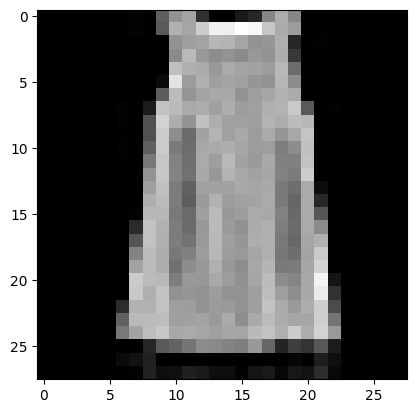

Label: 3


In [ ]:
# load the DataLoader itself
from torch.utils.data import DataLoader

# create a new DataLoader class instance for training and test
# reshuffle at every epoch
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

# once we create data loader, we cannot access elements by index
# now it is an itarable (ask for the next item as you read)
# go over every single batch
for i, data in enumerate(train_dataloader, 0):
  inputs, labels = data

# this is another way to iterate
# give us a tensor contaning 64 imgs and 64 corresponding labels
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [1]:
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip

--2025-11-22 11:21:33--  http://cs231n.stanford.edu/tiny-imagenet-200.zip
Resolving cs231n.stanford.edu (cs231n.stanford.edu)... 171.64.64.64
Connecting to cs231n.stanford.edu (cs231n.stanford.edu)|171.64.64.64|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://cs231n.stanford.edu/tiny-imagenet-200.zip [following]
--2025-11-22 11:21:34--  https://cs231n.stanford.edu/tiny-imagenet-200.zip
Connecting to cs231n.stanford.edu (cs231n.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248100043 (237M) [application/zip]
Saving to: ‘tiny-imagenet-200.zip’

tiny-imagenet-200.z 100%[===================>] 236.61M  10.4MB/s    in 27s     

2025-11-22 11:22:02 (8.62 MB/s) - ‘tiny-imagenet-200.zip’ saved [248100043/248100043]



In [2]:
!unzip -q tiny-imagenet-200.zip

In [4]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

dataset = ImageFolder(root="tiny-imagenet-200/train", transform=ToTensor())

#see total number of samples
#even dataset contains the train folder, ImageFolder
#implements the __len__ method such that, it looks at also in
#subfolders
print(f"Total number of samples: {len(dataset)}")



Total number of samples: 100000


In [6]:
# see all the available classes, ImageFolder finds
# same info exists also in wnids.txt file
print(dataset.classes)
# we can see how many classes it contains
# alternatively we can count the number of rows in wnids,txt
print(len(dataset.classes))

200


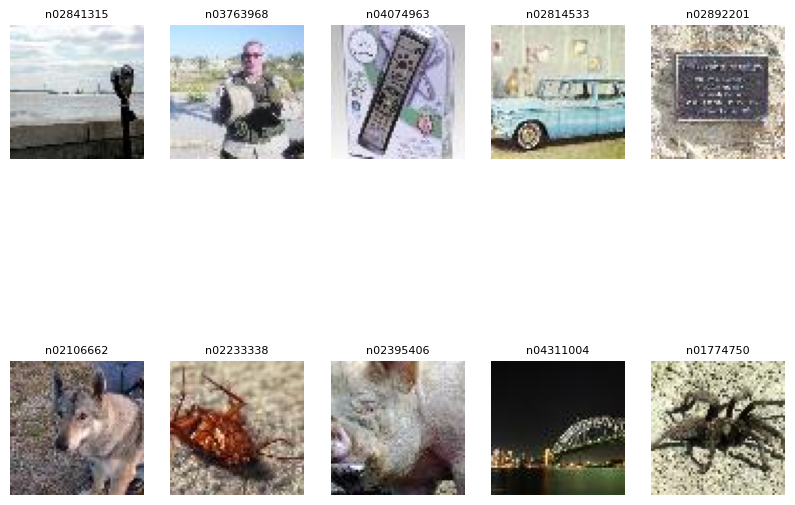

In [10]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch
# create a new DataLoader class instance for training and test
# reshuffle at every epoch
train_dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
for i, data in enumerate(train_dataloader, 0):
  inputs, labels = data

max_plots = 10
seen_labels = set()
# create a new canvas, for 10 inch wide and 8 incges tall
fig = plt.figure(figsize=(10, 8))
plot_count = 0

for inputs, labels in train_dataloader:
    # inputs is the batch of 64 images
    # labels is the batch of 64 labels

    # Loop through the 64 items in this batch:
    for j in range(len(labels)):
        current_label = labels[j].item()
        if current_label not in seen_labels:
            seen_labels.add(current_label)

            plot_count += 1

            if plot_count > max_plots:
                break

            # Access the image tensor for this item in the batch
            image_tensor = inputs[j].cpu().squeeze()

            fig.add_subplot(2, 5, plot_count) # 2 rows, 5 cols
            plt.axis("off")
            plt.title(dataset.classes[current_label], fontsize=8)
            plt.imshow(image_tensor.permute(1, 2, 0)) # Tiny ImageNet needs color handling (C, H, W -> H, W, C)

    if plot_count > max_plots:
        break

plt.show()

In [12]:
!git --version

!git config --global user.name "Matin Bayramli"
!git config --global user.email "matinbayramli9@gmail.com"



git version 2.34.1
